In [29]:
import sys
sys.dont_write_bytecode = True
%load_ext autoreload
%autoreload 1
%aimport classify_dice
import classify_dice
from ultralytics import YOLO
import sklearn
import cv2
from matplotlib import pyplot as plt
import numpy as np
import einops

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


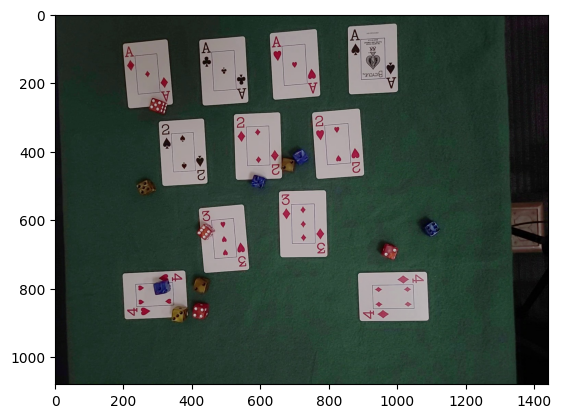

In [ ]:
obb_model = YOLO("model/rdg_obb/weights/best.pt")

# example_frame = "data/frames/frame_0214.jpg"
# example_frame = "data/additional_photos/raw/20251208_171417.jpg"
example_frame = "data/additional_photos/raw/20251208_182235.jpg"
img = cv2.imread(example_frame)
classify_dice.imshow(img)

In [76]:
res = obb_model(img, task='obb')[0]
res

0: 384x512 12 dies, 4 aces, 3 twos, 2 threes, 2 fours, 479.7ms
Speed: 9.4ms preprocess, 479.7ms inference, 13.2ms postprocess per image at shape (1, 3, 384, 512)


ultralytics.engine.results.Results object with attributes:

boxes: None
keypoints: None
masks: None
names: {0: 'die', 1: 'ace', 2: 'two', 3: 'three', 4: 'four'}
obb: ultralytics.engine.results.OBB object
orig_img: array([[[20, 25, 23],
        [21, 26, 24],
        [29, 33, 28],
        ...,
        [33, 26, 31],
        [28, 21, 24],
        [21, 14, 17]],

       [[18, 23, 21],
        [19, 24, 22],
        [28, 32, 27],
        ...,
        [32, 25, 30],
        [28, 21, 24],
        [23, 16, 19]],

       [[17, 22, 20],
        [17, 22, 20],
        [27, 31, 26],
        ...,
        [30, 23, 28],
        [27, 20, 25],
        [24, 17, 22]],

       ...,

       [[11, 11, 11],
        [11, 11, 11],
        [11, 11, 11],
        ...,
        [ 2,  2,  2],
        [ 2,  2,  2],
        [ 2,  2,  2]],

       [[11, 11, 11],
        [11, 11, 11],
        [11, 11, 11],
        ...,
        [ 2,  2,  2],
        [ 2,  2,  2],
        [ 2,  2,  2]],

       [[11, 11, 11],
        [11, 11,

In [77]:
res[0].obb

ultralytics.engine.results.OBB object with attributes:

cls: tensor([3.])
conf: tensor([0.9655])
data: tensor([[493.3721, 653.5632, 200.1582, 129.5010,   1.5234,   0.9655,   3.0000]])
id: None
is_track: False
orig_shape: (1080, 1440)
shape: torch.Size([1, 7])
xywhr: tensor([[493.3721, 653.5632, 200.1582, 129.5010,   1.5234]])
xyxy: tensor([[423.9544, 550.5298, 562.7898, 756.5967]])
xyxyxyxy: tensor([[[433.4341, 756.5967],
         [562.7898, 750.4634],
         [553.3101, 550.5298],
         [423.9544, 556.6631]]])
xyxyxyxyn: tensor([[[0.3010, 0.7006],
         [0.3908, 0.6949],
         [0.3842, 0.5097],
         [0.2944, 0.5154]]])

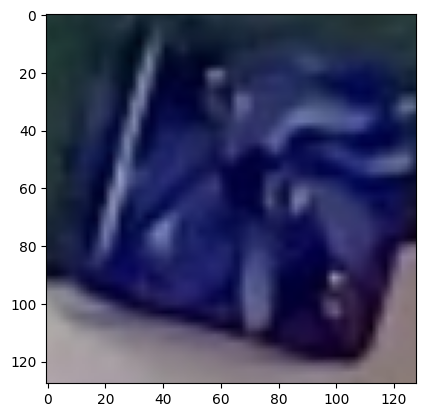

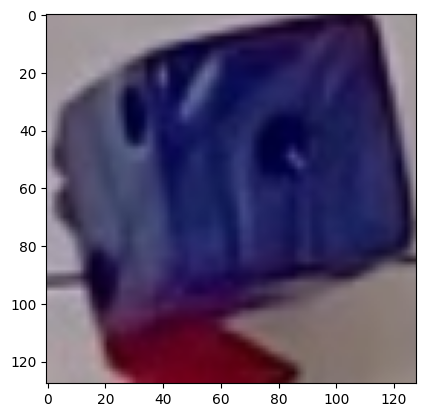

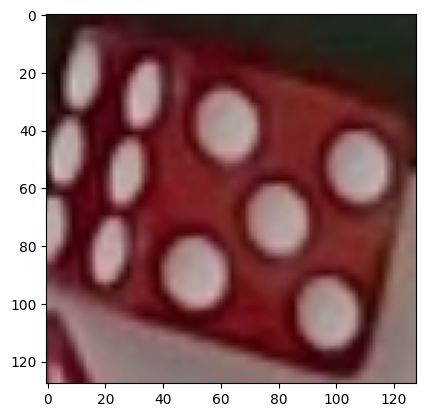

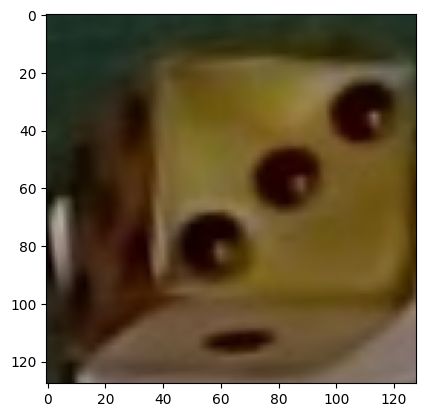

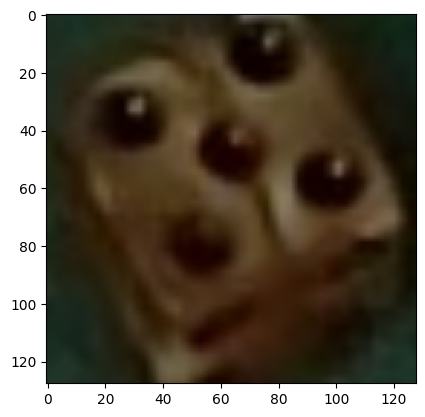

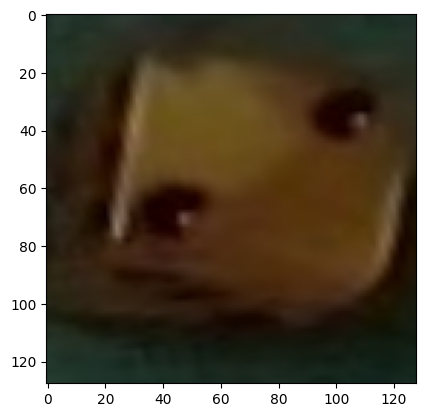

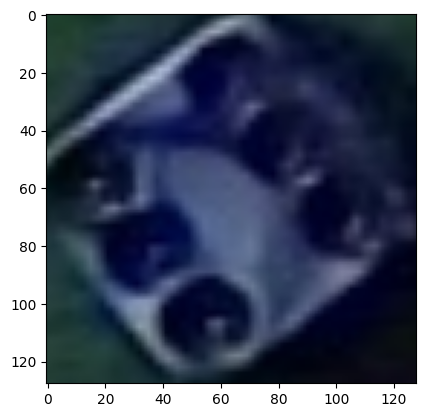

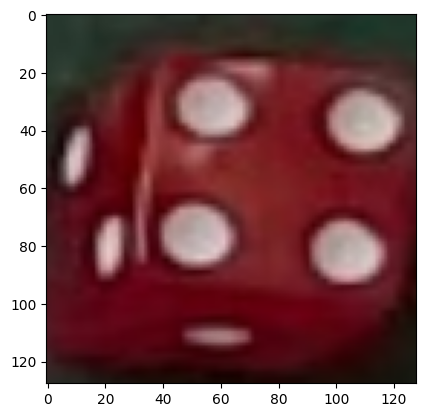

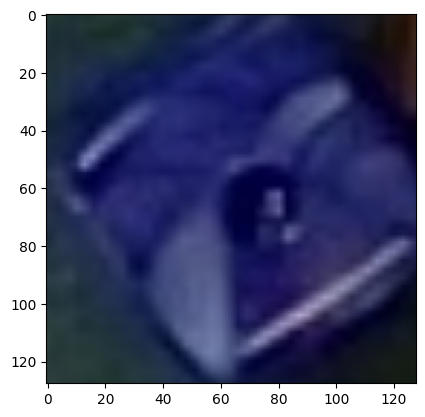

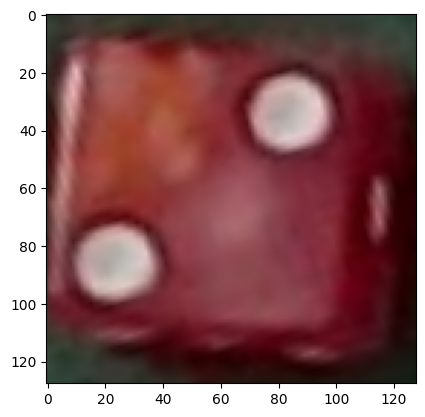

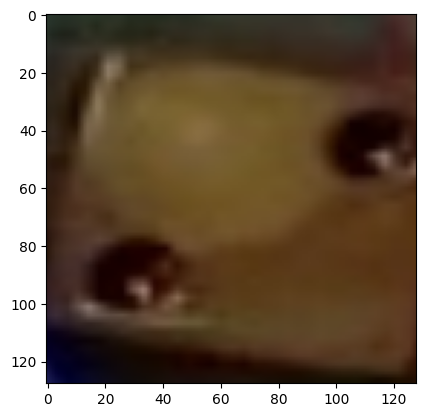

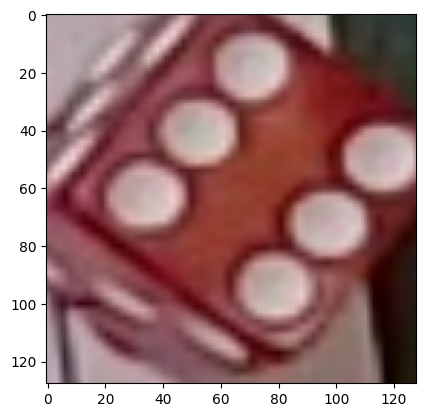

In [78]:
dice_cropped = classify_dice.batch_crop_dice(img, res)

for die_idx in range(dice_cropped.shape[0]):
    plt.figure()
    classify_dice.imshow(dice_cropped[die_idx,:,:,:])

In [79]:
k_means,palette = classify_dice.kmeans_color(dice_cropped, k=16)

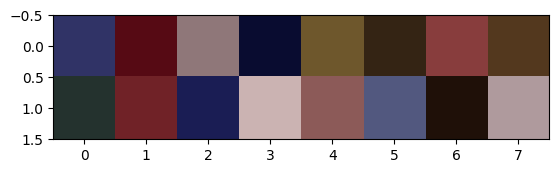

In [80]:
classify_dice.imshow(einops.rearrange(palette, "(h w) C -> h w C", w=8))

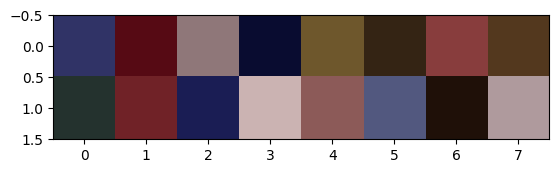

In [81]:
classify_dice.imshow(einops.rearrange(palette, "(h w) C -> h w C", w=8))

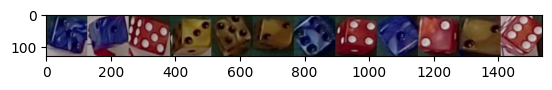

In [82]:
classify_dice.imshow(einops.rearrange(dice_cropped, "N H W C-> H (N W) C"))

<Figure size 640x480 with 0 Axes>

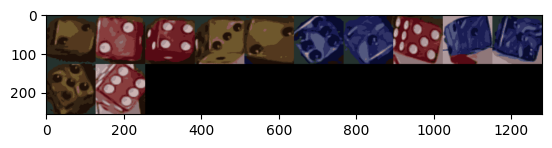

(973, 128, 128, 3)


<Figure size 640x480 with 0 Axes>

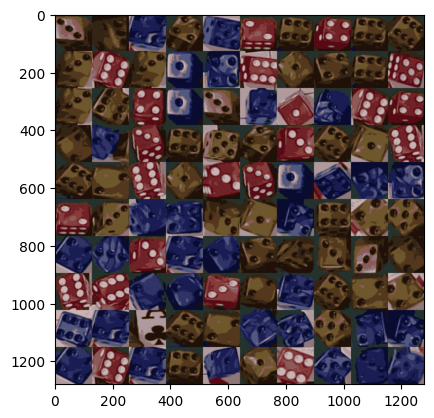

In [83]:
# recolor dice using this limited palette


classes,posterized = classify_dice.posterize(dice_cropped, k_means, palette)
sample_idxs = np.random.permutation(posterized.shape[0])[:100]
plt.figure()
# classify_dice.imshow(einops.rearrange(posterized[sample_idxs,...], "(N x) H W C -> (N H) (x W) C", x=4))
classify_dice.show_imgs_grid(posterized[sample_idxs,...], width=10)
plt.show()

# all_dice = classify_dice.generate_dice_dataset(obb_model)
all_dice = np.load('data/dice/all_dice.npz')['arr_0']
print(all_dice.shape)
_,all_dice_posterized = classify_dice.posterize(all_dice, k_means, palette)
sample_idxs = np.random.permutation(all_dice_posterized.shape[0])[:100]
plt.figure()
classify_dice.show_imgs_grid(all_dice_posterized[sample_idxs,...], width=10)
plt.show()


In [84]:
limgs,lids,lplayers,lvalues = classify_dice.load_labeled_dice()

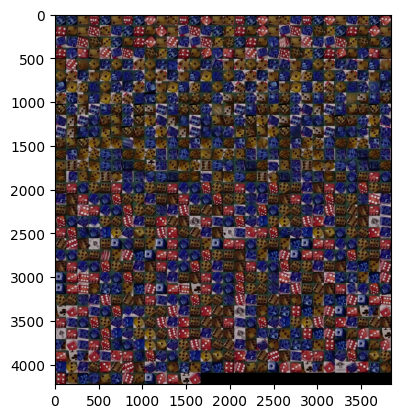

In [85]:
classify_dice.show_imgs_grid(all_dice,width=30)

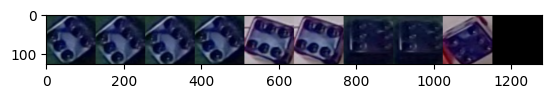

In [86]:
mask=(lplayers==2)&(lvalues==6)
classify_dice.show_imgs_grid(limgs[mask], width=10)

lids[bad_idx]=np.int64(938)


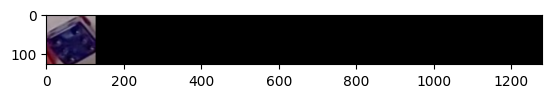

In [87]:
bad_idx = np.argwhere(np.cumsum(mask)==9)[0,0]
print(f"{lids[bad_idx]=}")
classify_dice.show_imgs_grid(limgs[[bad_idx],:,:,:])

np.int64(760)

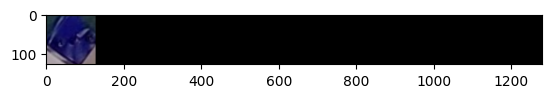

In [88]:
classify_dice.show_imgs_grid(limgs[[154],:,:,:])
lids[154]

In [89]:
# np.savez_compressed('data/dice/all_dice.npz', all_dice.astype(np.uint8))

In [68]:
# classify_dice.write_dice()

In [90]:
# def to_histogram(imgs):
#     N,H,W,C = imgs
classes,posterized = classify_dice.posterize(limgs, k_means, palette)


In [91]:
flattened_classes = einops.rearrange(classes, "N H W -> N (H W)")

histograms = np.zeros((flattened_classes.shape[0], palette.shape[0]))
for i in range(flattened_classes.shape[0]):
    histograms[i,:] = np.bincount(flattened_classes[i,:], minlength=palette.shape[0])
    histograms[i,:] /= histograms[i,:].sum()
# einops.reduce()
# np.bincount(flattened_classes, minlength=16)

# sklearn.d

histograms


array([[          0,     0.25391,    0.034851, ...,           0,    0.089783,    0.063171],
       [          0,           0,   0.0032349, ...,           0,    0.055176,           0],
       [          0,     0.27069,    0.036499, ...,           0,     0.10529,     0.05957],
       ...,
       [          0,     0.12732,    0.032898, ...,           0,    0.074341,    0.075623],
       [  0.0065918,           0,    0.046326, ...,           0,     0.13696,   0.0018311],
       [  0.0062256,    0.063354,    0.072571, ...,   0.0023193,    0.013184,     0.13763]], shape=(186, 16))

In [92]:
pca = sklearn.decomposition.PCA(n_components=2, whiten=True, random_state=1337)
hist_pca = pca.fit_transform(histograms)


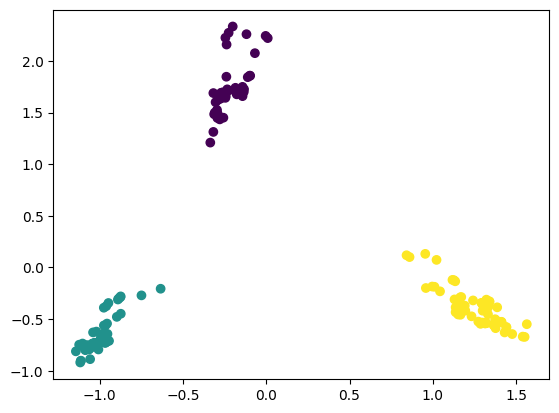

In [93]:
plt.scatter(hist_pca[:,0], hist_pca[:,1], c=lplayers)

pst.shape=(1, 1080, 1440, 3)


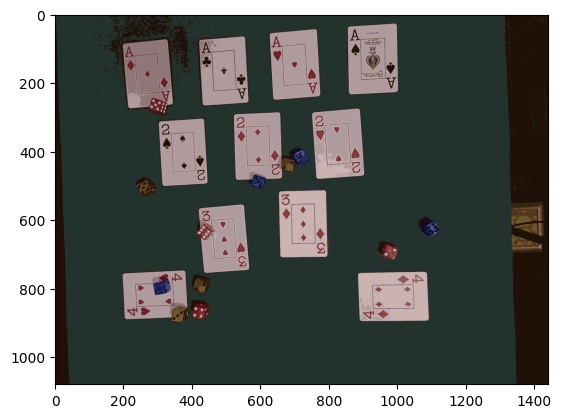

In [98]:
# classify_dice.imshow(classify_dice.posterize(img[None,:,:,:], k_means, palette))
# classify_dice.imshow()

_,pst = classify_dice.posterize(img[None,:,:,:], k_means, palette)
print(f"{pst.shape=}")
classify_dice.imshow(pst[0,:,:,:])


[[    0.38532    -0.24383]
 [   -0.33669       1.269]
 [      1.863    -0.67908]
 [     -1.162     -1.2302]
 [    0.13269     0.98661]
 [    0.72519   -0.017353]
 [    -1.1987    -0.71424]
 [    -1.2962    -0.97349]
 [   -0.15842       3.787]
 [     1.8144    -0.76025]
 [    -1.3254    -0.98157]
 [     1.4387    -0.43046]
 [    0.50461     0.11711]
 [   0.061043     0.99035]
 [   -0.11537      2.8221]
 [   0.058557      1.1722]]


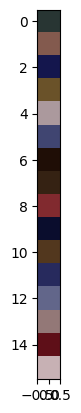

In [ ]:
print(pca.transform(np.eye(16)))
classify_dice.imshow(einops.rearrange(palette, "N C -> N 1 C"))

0
1
2
2 open
3
4
5
6
7
8
9


[ WARN:0@2840.739] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@2840.740] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
[ WARN:0@2840.740] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video1): can't open camera by index
[ERROR:0@2840.741] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
[ WARN:0@2840.748] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video3): can't open camera by index
[ERROR:0@2840.750] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
[ WARN:0@2840.754] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video4): can't open camera by index
[ERROR:0@2840.756] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
[ WARN:0@2840.756] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video5): can't open camera by index
[ERROR:0@2840.760] global obsensor_uvc_stream_channel.c

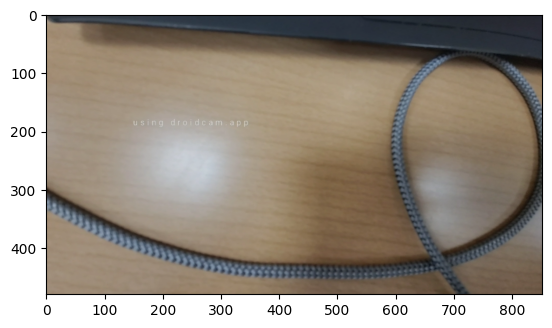

In [27]:
for idx in range(10):
    print(idx)
    cap = cv2.VideoCapture(idx)
    if cap.isOpened():
        print(idx, 'open')
    cap.release()
cv2.destroyAllWindows()

cap = cv2.VideoCapture(2)
img = cap.read()[1]
cap.release()
classify_dice.imshow(res[1])
# res[1]